# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [4]:
df.describe() # 144015 observations found

,Trip ID,Duration,Start Terminal,End Terminal,Bike #
count,144015.000000,144015.000000,144015.000000,144015.000000,144015.000000
mean,100967.962129,1230.910141,56.925515,56.943548,437.029407
std,56121.284410,6652.962329,17.372388,17.366134,138.076365
min,4069.000000,60.000000,2.000000,2.000000,9.000000
25%,52138.500000,349.000000,50.000000,49.000000,349.000000
50%,99969.000000,531.000000,61.000000,61.000000,446.000000
75%,150090.500000,797.000000,70.000000,70.000000,546.000000
max,198775.000000,722236.000000,83.000000,83.000000,717.000000


Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [5]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("#", "num")
)

In [6]:
df.columns

Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='str')

How many types of subscription options are there? What are the different subscription types?

In [ ]:
df['subscription_type'].unique() # There are 2 types of subscription types

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

What is the frequency of each subscription option?

In [ ]:
df['subscription_type'].value_counts() # Subscriber are 3x more than Customer type

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

Please plot the frequency of each subscription option with a pie chart:

<Axes: >

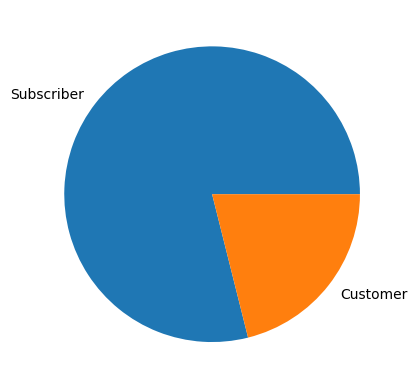

In [9]:
df['subscription_type'].value_counts().plot(kind='pie')

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='subscription_type'>

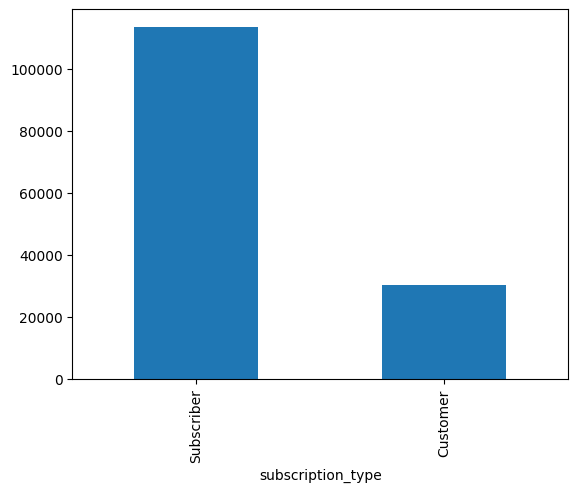

In [11]:
df['subscription_type'].value_counts().plot(kind='bar')

Have a look at the start_station column: Which 10 stations occur most frequently?

In [12]:
df['start_station'].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [13]:
df['end_station'].value_counts().tail(10)

end_station
Broadway St at Battery St           205
Redwood City Medical Center         178
Castro Street and El Camino Real    129
Redwood City Public Library         117
San Mateo County Center             106
Franklin at Maple                    93
San Antonio Shopping Center          93
Broadway at Main                     56
San Jose Government Center           23
Mezes Park                            5
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [14]:
pd.crosstab(
    df['start_station'],
    df['subscription_type'],
    margins=True
)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

The duration appears to be measured in seconds since the shortest trip was 60.

In [17]:
df[df['duration']==60].shape[0]

17

What do you think is going on with the short trips?

Maybe test rides, technical errors, reserved by mistake etc. It would be mostly instant cancel for several reasons.

What is the longest trip?

In [20]:
df[df['duration'] == df['duration'].max()]

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
80510,111309,722236,11/30/2013 13:29,University and Emerson,35,12/8/2013 22:06,University and Emerson,35,247,Customer,94301


How would you define a "long" trip? How many trips are "long" according to your definition?

The 75th percentile of trip duration is around 12 minutes. Therefore, trips longer than this could be considered relatively long trips in this dataset.

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

The longest trip lasted several days, which is unusually long. This is likely caused by technical issues, users forgetting to return the bike in the system, or other data anomalies.

Plot the duration column.

Text(0.5, 1.0, 'Distribution of Trip Duration')

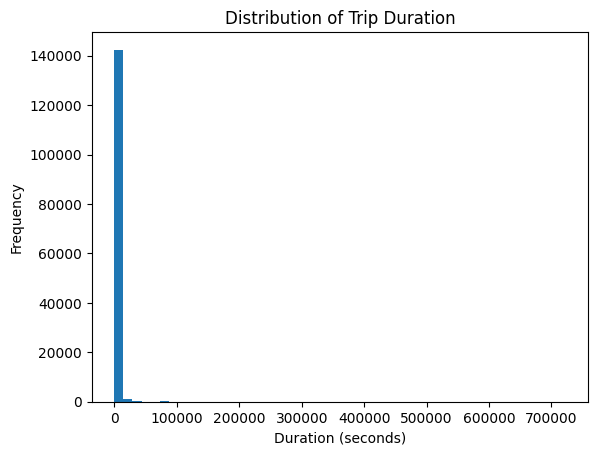

In [22]:
plt.hist(df['duration'], bins=50)
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Duration")

Does this plot give any insights?

The distribution is highly right-skewed. Most trips are relatively short, while a small number of trips have extremely long durations, which may represent outliers or data recording issues.

Select subsections of the data to make plots that provide more insights.

<Axes: ylabel='Frequency'>

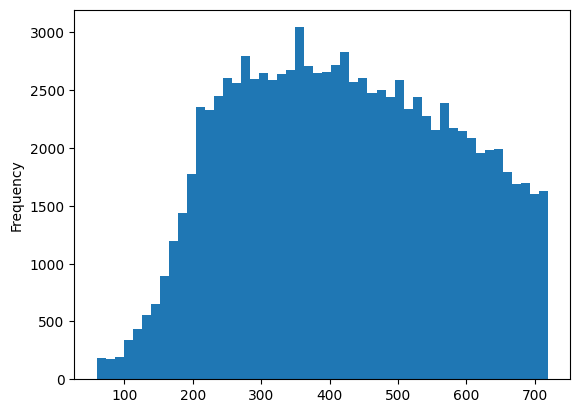

In [ ]:
df[df['duration'] < 720]['duration'].plot.hist(bins=50) # Only plotted 75% of the data (i.e., 12 min which is the short trip defined above)

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [27]:
df['start_station'] = df['start_station'].str.lower().str.replace(" ", "_", regex=False)
df['end_station'] = df['end_station'].str.lower().str.replace(" ", "_", regex=False)

In [28]:
df

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,south_van_ness_at_market,66,8/29/2013 14:14,south_van_ness_at_market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,san_jose_city_hall,10,8/29/2013 14:43,san_jose_city_hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,mountain_view_city_hall,27,8/29/2013 10:17,mountain_view_city_hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,san_jose_city_hall,10,8/29/2013 11:30,san_jose_city_hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,south_van_ness_at_market,66,8/29/2013 12:04,market_at_10th,67,319,Subscriber,94103
...,...,...,...,...,...,...,...,...,...,...,...
144010,198771,385,2/28/2014 22:15,powell_street_bart,39,2/28/2014 22:22,south_van_ness_at_market,66,483,Subscriber,94404
144011,198772,145,2/28/2014 22:38,commercial_at_montgomery,45,2/28/2014 22:40,davis_at_jackson,42,425,Subscriber,94111
144012,198773,677,2/28/2014 22:45,embarcadero_at_sansome,60,2/28/2014 22:56,market_at_4th,76,438,Subscriber,94102
144013,198774,64128,2/28/2014 23:01,civic_center_bart_(7th_at_market),72,3/1/2014 16:50,harry_bridges_plaza_(ferry_building),50,414,Customer,94124


Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 

In [29]:
df.groupby('subscription_type')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
subscription_type,,,,,,,,
Customer,30368.0,3629.519659,13182.359544,61.0,637.0,1068.0,2063.25,722236.0
Subscriber,113647.0,589.969564,2776.223684,60.0,319.0,471.0,665.00,619322.0


In [30]:
df.groupby(['start_station','end_station']).size().sort_values(ascending=False).head(10)

start_station                             end_station                             
harry_bridges_plaza_(ferry_building)      embarcadero_at_sansome                      1330
townsend_at_7th                           san_francisco_caltrain_(townsend_at_4th)    1322
san_francisco_caltrain_2_(330_townsend)   townsend_at_7th                             1116
market_at_sansome                         2nd_at_south_park                            866
embarcadero_at_sansome                    steuart_at_market                            811
2nd_at_south_park                         market_at_sansome                            798
san_francisco_caltrain_(townsend_at_4th)  harry_bridges_plaza_(ferry_building)         782
2nd_at_townsend                           harry_bridges_plaza_(ferry_building)         757
steuart_at_market                         embarcadero_at_sansome                       717
harry_bridges_plaza_(ferry_building)      2nd_at_townsend                              710
dtype: 

In [31]:
(df['start_station'] == df['end_station']).sum()

np.int64(6878)

I explored several aspects of the dataset. Most trips appear to be relatively short, with a heavily right-skewed distribution. Subscriber trips tend to be shorter than customer trips, which may indicate commuting behavior. Some stations appear significantly more frequently as starting points, suggesting popular commuting spots.